# Monte Carlo


gera numeros aleatórios, ve se ta dentro ou fora da condição do exercicio

## Radioactive decay chain


${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
tau = 3.052 * 60 #minutes to seconds
Tl_i = 1000 # atoms
Pb_i = 0 # atoms - initial sample
dt = 1 #1 second step
p_decay = 1 - 2**(-dt/tau)
T_max = 1500        # total time (seconds)

Tl_hist = [] #final tl: tl - decayed
Pb_hist = [] #final pb: pb + decayed


#como eu tenho q calcular a probabilidade em cada step, um arrange de cada tempo a ser calculado
times = np.arange(0, T_max, dt)

In [ ]:
#Monte carlo: draw a random number between 0 and 1, if it is smaller than p_decay, then the atom decays
np.random.seed(42) #seed for reproducibility
for i in range(len(times)):
    
    num_dec = np.sum(np.random.random(Tl_i) < p_decay) #since we're deciding over the number of atoms the prob

    Tl_i -= num_dec #Altera o numero de Tl_i, diminuindo o numero de decaidos
    Pb_i += num_dec

    Tl_hist.append(Tl_i)
    Pb_hist.append(Pb_i) #salva o historico

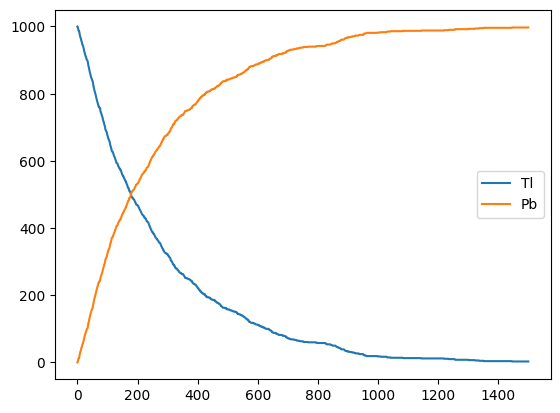

In [8]:
plt.plot(np.linspace(0,T_max,1500),Tl_hist, label = 'Tl')
plt.plot(np.linspace(0,T_max,1500),Pb_hist, label = 'Pb')
plt.legend()

In [17]:
# Inverse transform method:
N = 1000 #number of random draws

#pdf: 
#pdf_t = np.log(2)/tau * 2**(-t/tau)
#cdf: integral de pdf de 0 a t
#cdf_t = 1 - 2**(-t/tau)
#inverse cdf -> U = F(t) e depois isola t
T_inverse_cdf = (-tau/np.log(2))*(np.log(1 - np.random.random(N))) #draws from uniform distribution

Tl_alive = []

for t in times:
    alive = np.sum(T_inverse_cdf > t) #mostra quantos ainda estao vivos em cada segundo do tempo
    Tl_alive.append(alive)

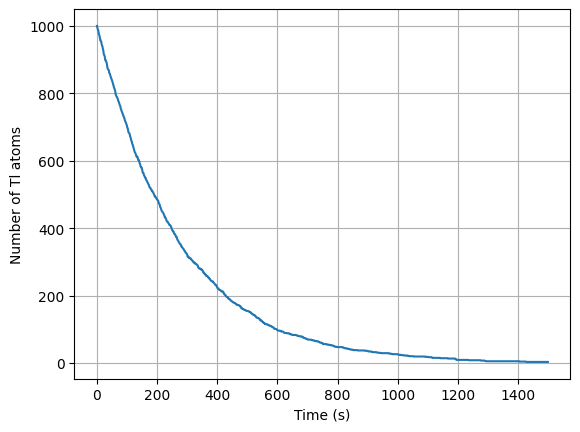

In [18]:
plt.plot(times, Tl_alive)
plt.xlabel("Time (s)")
plt.ylabel("Number of Tl atoms")
plt.grid()

### Summarize:

**primeira parte:** 
* cria as variaveis
* cria as listas de tl e pb
* cria a 'linha de tempo - arange'
* for i in times:
* soma de np.random.random(atomos de tl) < prob
* sub em tl; add em pb
* plota

**segunda parte:**
* tem a pdf: integra pra cdf
* u = F(T) -> isola T
* obtem a funcao q transforma a uniforme em tempo
* lista de t historico alive
* for t in times:
* se o tempo_morreu(inverse cdf) > t -> vivo
* append of ta vivo
* plota ao longo do tempo

## Rutherford Scattering

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [19]:
import scipy.constants as const

In [22]:
print(const.physical_constants["Bohr radius"])
print(const.physical_constants["Bohr radius"][0])

(5.29177210544e-11, 'm', 8.2e-21)
5.29177210544e-11


In [29]:
Z = 79 #nucleus of gold 
E = 7.7e6 * const.eV #Mev to Joules
a0 = const.physical_constants["Bohr radius"][0]
e = const.e
epsilon_0 = const.epsilon_0
sigma = a0/100
N_alpha = 10**6
angle_crit = np.pi/2
b_crit = Z*(e**2)/(2*np.pi*epsilon_0*E)

In [30]:
#Now to generate the 2D Gaussian distribution
np.random.seed(42) #seed for reproducibility
x = np.random.normal(0, sigma, N_alpha) #centro do ouro em (0,0)
y = np.random.normal(0, sigma, N_alpha) 

#given that b is the distance from the center, them:
b = np.sqrt(x**2 + y**2)

#to know what bounced:
n_bounce = np.sum(b < b_crit) #se b for menor que o threshold, entao bounce
fraction_bounce = n_bounce/N_alpha

In [33]:
print(n_bounce,'\n',fraction_bounce*100)

1534 
 0.1534


### Summarize:

* scipy.constants - tem tudo la
* transformar E em Joule: E(joule) = E(mev) * 10**6 * constante.eV
* tan $\pi/4$ = 1
* b pequeno -> $\theta$ grande, então o angulo tem que ser maior que  $\pi/2$
* isola b
* substitui tudo
* gera duas normais para x e y (0,sigma)
* b é a distancia (euclidiana de x e y)
* b < b critico -> então bounce

## Monte Carlo integration: hit/miss vs mean value method


Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [48]:
#Hit and miss method:está no monte carlo notebook
def f(x):
    return np.sin(1/(x*(2-x)))**2

#integration limits:
a,b = 0.0001, 1.9999 #avoid singularities at 0 and 2
N = 1000000 #number of random draws
np.random.seed(42)

In [52]:
x=np.linspace(a,b,1000)
count=0
for i in range(N):
    x=2*np.random.random() #se tor integrando de 0 a 2, np random gera de 0 a 1
    y=np.random.random() #pq a funcão sin vai no maximo a 1
    if y<f(x): count+=1 #se estiver dentro da função é success
I=2*count/N #2 é a area

#para calcular o erro: area * raiz(hits *(n-hits)/N)
error = 2 * np.sqrt((count/N) * (1 - count/N) / N)

print(I, "+-", error)

1.451112 +- 0.0008924673458765872


In [55]:
#Mean Value Method
for i in range(N):
    I = (2 / N) * np.sum(f(x))
errormv = 2 * np.std(f(x)) / np.sqrt(N) #erro do mean value method    
print(I, "+-", errormv)    

1.4565556008016826e-06 +- 0.0


### Summarize:
* def f(x)
* pega do notebook de montecarlo o hit and miss
* nao deixa exatamente 0 e 2, para evitar singularities
* calcula a area do retangulo baseado nos limites da função
* erro hit miss: area * sqrt((count/N) * (1 - count/N) / N)
* para mean value só aplicar a formula do enunciado

## Monte Carlo integration in high dimension

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere


In [66]:
N = 1000000 #number of random draws
#To compute the area do a circle with radius 1
x = np.random.uniform(-1, 1, N) # podem cair em qualquer ponto do quadrado de area 2x2
y = np.random.uniform(-1, 1, N)

rinside2 = x**2 + y**2 <= 1 #aqui aplico minha condição

hits = np.sum(rinside2)

areacirculo = (4/N)*hits #area quadrado * hits / N

erro = 2**2 * np.sqrt(np.var(rinside2)/N) #area do quadrado * raiz(variancia/N)
print(areacirculo, "+-", erro)


3.1402959999999998 +- 0.001643084000404118


In [65]:
#generalizando para 10D:
points = np.random.uniform(-1, 1, size=(N,10))
r2 = np.sum(points**2, axis=1) #raio ao quadrado de cada ponto de 10D
rinside = r2 <= 1 #pontos dentro do hiperesfera de raio 1
hits = np.sum(rinside)

I = 2**10 * hits / N #area do hipercubo(-1 a 1 é 2)

sigma_10 = 2**10 * np.sqrt(np.var(r2)/N)
print(I ,"+-", sigma_10)

2.678784 +- 0.9658446963560243


### Summarize:
* define o d(dimensoes), vai ficar mais facil para generalizar
* x e y se o raio é 1, então vai de -1 a 1 RANDOM UNIFORM para poder setar o intervalo dos numeros a serem gerados
* a condição é do raio ao quadrado <= 1 - distancia dos pontos (soma euclidiana)
* I segue a formula do notebook
* var f(x) - var (rinside)


## Monte Carlo integration with importance sampling

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [72]:
def f(x):
    return x**(-0.5)/(1 + np.exp(x))
def w(x):
    return x**(-0.5) #weight function
def g(x):
    return 1/(1 + np.exp(x)) #f(x)/w(x)
N = 1000000
a, b = 0,1
#pelos calculos de cdf:
u = np.random.uniform(a,b,N) #draws from uniform distribution
x = u**2

#NO FINAL:
I = (2 * np.sum(g(x)))/N #mas tenho que gerar os x de 1 a N - nao precisa do loop pq os numeros ja estão sendo gerados até N
print(I)

0.8387940784779782


### Summarize:
* faz os calculos manuais de acordo com as deduções do notebook
* calcula integral de w(x)
* calcula a pdf -> p(x) = w(x)/integral w(x) -> pois deve ser normalizada de 0 a 1
* obtem a CDF: F(X) = integral de 0 a x de p(t)
* como é entre 0 e 1: F(X) = u -> x = u**2
* u = np.random
* x = u**2
* I = (2 * np.sum(g(x)))/N

# Algorithms (FFT)

## Maximum wind speed prediction at the Sprogø station

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```

In [88]:
#annual maxima fit a pdf
#maximum wind speed every 50 years is 2% upper quantile
#quantile: inverse of cdf
import numpy as np
from scipy.interpolate import UnivariateSpline
max_speeds = np.load("max-speeds.npy")
years_nb = max_speeds.shape[0]

cprob = np.arange(1, years_nb + 1) / (years_nb + 1) # o p_i = i/(N+1) - entao p tem que ser feito para cada i
sorted_speeds = np.sort(max_speeds) #ordena os valores de max speed
quantile_func = UnivariateSpline(cprob, sorted_speeds, s=0.9) #sem smoothing
fifty_prob = 1. - 0.02 #2% upper quantile
fifty_wind = quantile_func(fifty_prob)

In [89]:
print(cprob)
print(sorted_speeds)
print(f"\n=== 50-year maximum wind speed ===")
print(f"Probability: {fifty_prob}")
print(f"Estimated wind speed: {fifty_wind:.2f} m/s")

[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545]
[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]

=== 50-year maximum wind speed ===
Probability: 0.98
Estimated wind speed: 35.44 m/s


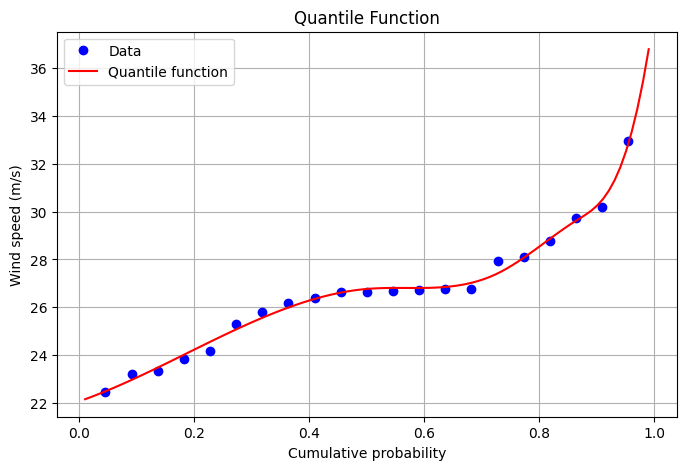

In [90]:
p_range = np.linspace(0.01, 0.99, 100)
plt.figure(figsize=(8, 5))
plt.plot(cprob, sorted_speeds, 'bo', label='Data')
plt.plot(p_range, quantile_func(p_range), 'r-', label='Quantile function')
plt.xlabel('Cumulative probability')
plt.ylabel('Wind speed (m/s)')
plt.title('Quantile Function')
plt.legend()
plt.grid(True)
plt.show()

### Summarize:
* importa tudo e escreve as funcoes
* lembrar que p tem que iterar para cada i - entao arange
* SORT MAX SPEEDS
* s = 0 para interpolar em todos os pontos
* quantile_func vai ser a Univariate Spline
* plotar cprob x sorted speeds
* plotar os pontos = linspance x quantile_func em cada ponto da cdf

## Curve fitting of temperature in Alaska

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

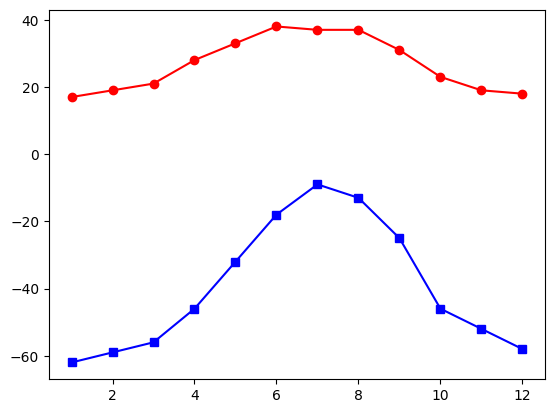

In [98]:
max_temp = [17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18]
min_temp = [-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58]
months = np.arange(1,13)

plt.plot(months, max_temp, 'ro-', label='Max Temp')
plt.plot(months, min_temp, 'bs-', label='Min Temp')



In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [119]:
# o segredo aqui pe que voce precisa CRIAR uma função que fit nessas curvas
#pela aparencia entendemos que funçaõ seno se aproxime bem, modificada pela amplitude e deslocamento vertical
def temp_func(month,avg,amp,offset):
    T = avg + amp*np.sin((month/12)*2*np.pi + offset) #o 2pi é pq a função seno tem periodo 2pi, e o offset é o deslocamento de fase
    return T
#avg = temperatura média anual
#amp = amplitude da variação sazonal
#offset = descolamento de fase

# Initial guesses: [amplitude, phase, mean]
p0_max = [10, 7, np.mean(max_temp)]  #amplitude: maior - menor div por 2 : aprox 40 - 20 / 2
p0_min = [26, 7, np.mean(min_temp)]  

Max fit: A=26.75, phase=-10.93, mean=26.32
Min fit: A=-39.67, phase=25.58, mean=-39.88


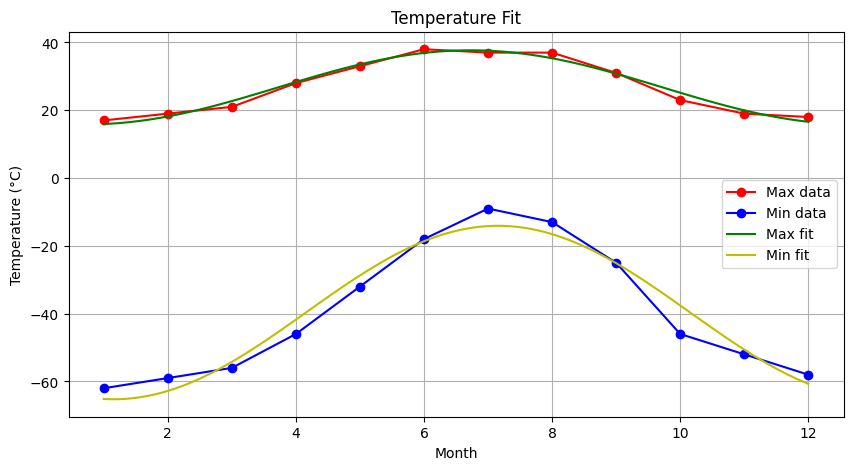

In [120]:
# Fit
popt_max, covmax = curve_fit(temp_func, months, max_temp, p0=p0_max)
popt_min, covmin = curve_fit(temp_func, months, min_temp, p0=p0_min)

print(f"Max fit: A={popt_max[0]:.2f}, phase={popt_max[1]:.2f}, mean={popt_max[2]:.2f}")
print(f"Min fit: A={popt_min[0]:.2f}, phase={popt_min[1]:.2f}, mean={popt_min[2]:.2f}")

# Plot fit
x_fine = np.linspace(1, 12, 100)
plt.figure(figsize=(10, 5))
plt.plot(months, max_temp, 'ro-', label='Max data')
plt.plot(months, min_temp, 'bo-', label='Min data')
plt.plot(x_fine, temp_func(x_fine, *popt_max), 'g-', label='Max fit')
plt.plot(x_fine, temp_func(x_fine, *popt_min), 'y-', label='Min fit')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.title('Temperature Fit')
plt.grid(True)
plt.show()


### Summarize:

* cria as listas e plota - meses: arange(1,13)
* cria uma função que combine: SENOIDAL: mean + variação de temperatuda
* variação: amp*sin(aquele mes/12 * 2pi + offset(onde é max))
* faz os initial guesses: amp: maior - menor /2; mean = mean(max_/min_); offset: 6 ou 7
* segue o notebook e documentação de curve fit

## FFT of an image

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

In [99]:
import numpy as np
from scipy import fftpack
from matplotlib import pyplot as plt


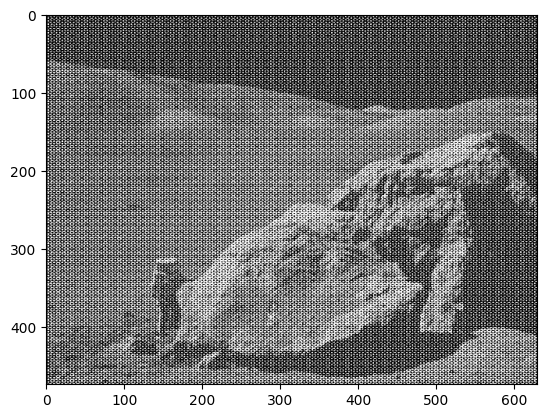

In [104]:
img = plt.imread("moonlanding.png", format='png')
plt.imshow(img, cmap='gray')

In [122]:
F = fftpack.fft2(img) #fft2 é pq é 2D
F_shifted = fftpack.fftshift(F) #shift the zero frequency component to the center of the spectrum

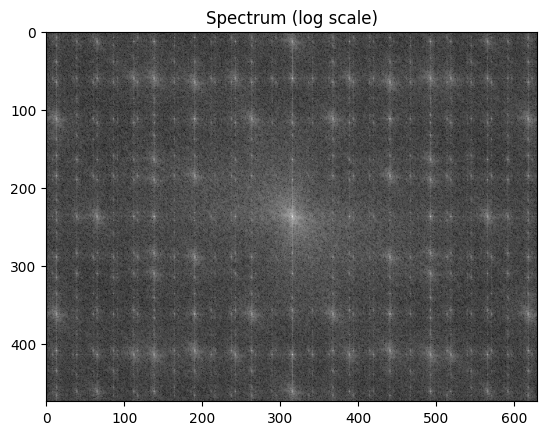

In [128]:
plt.imshow(np.log(np.abs(F_shifted) + 1), cmap='gray')
plt.title('Spectrum (log scale)')
plt.show()

In [131]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
mask = np.zeros((rows, cols))
r = 60 
y, x = np.ogrid[:rows, :cols]
mask_area = (x - ccol)**2 + (y - crow)**2 <= r**2
mask[mask_area] = 1

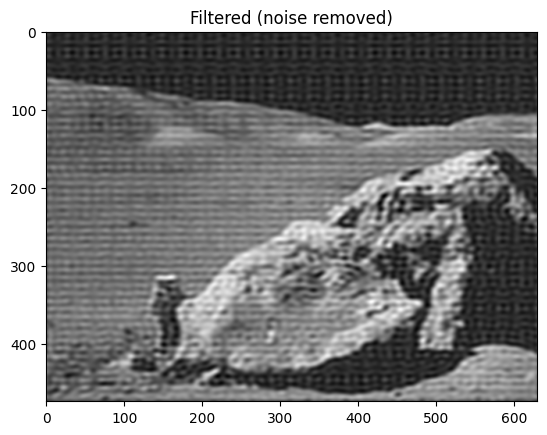

In [132]:
F_filtered = F_shifted * mask

# === Inverse FFT ===
F_ishifted = fftpack.ifftshift(F_filtered)
img_filtered = np.real(fftpack.ifft2(F_ishifted))

plt.imshow(img_filtered, cmap='gray')
plt.title('Filtered (noise removed)')
plt.show()


### Summarize:
* Load image (you need moonlanding.png in the folder)

*  === Original image ===
plt.imshow(img, cmap='gray')

*  === 2D FFT ===
F = fftpack.fft2(img)
F_shifted = fftpack.fftshift(F)  # center the zero frequency

* Plot spectrum (use log scale for visibility!)
plt.imshow(np.log(np.abs(F_shifted) + 1), cmap='gray')

* === Filter high frequencies (noise) ===
* Create a mask to keep low frequencies (center of spectrum)

* Low-pass filter: keep center (low freq), remove outer (high freq = noise)
* Step 1: Initialize mask as all zeros (0 = block frequency, 1 = keep frequency)

* Step 2: Define radius of circular region to preserve
r =  radius in pixels - larger r = more frequencies kept = less blur but more noise

* Step 3: Create coordinate grids for each pixel position
* np.ogrid creates "open" grids efficiently:
*   y is a column vector: [[0], [1], [2], ..., [rows-1]]  (shape: rows×1)
*   x is a row vector: [[0, 1, 2, ..., cols-1]]           (shape: 1×cols)
* When used in operations, broadcasting automatically creates full 2D grids

* Step 4: Circle equation to identify pixels inside the circle
* For each pixel at position (x, y), calculate: (x - center_x)² + (y - center_y)² ≤ r²
* This creates a boolean array: True = inside circle, False = outside circle
* The circle is centered at (crow, ccol), which is the center of the FFT spectrum
* (center = low frequencies, edges = high frequencies)

* Step 5: Set mask to 1 for pixels inside the circle (keep these frequencies)
* All other pixels remain 0 (block these frequencies)
* Result: circular white disk (1) in center, black (0) everywhere else

* Apply mask
* === Inverse FFT ===

# Exam Version 1

## Analyze a data file 

  * Download the population of hares, lynxes and carrots at the beginning of the last century.
    ```python
    ! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
    ```

  * Check the content by looking within the file
  * Load the data (use an appropriate numpy method) into a 2D array
  * Create arrays out of the columns, the arrays being (in order): *year*, *hares*, *lynxes*, *carrots* 
  * Plot the 3 populations over the years
  * Compute the main statistical properties of the dataset (mean, std, correlations, etc.)
  * Which species has the highest population each year?

Do you feel there is some evident correlation here? [Studies](https://www.enr.gov.nt.ca/en/services/lynx/lynx-snowshoe-hare-cycle) tend to believe so.

In [135]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("populations.txt")
print(data)

[[ 1900. 30000.  4000. 48300.]
 [ 1901. 47200.  6100. 48200.]
 [ 1902. 70200.  9800. 41500.]
 [ 1903. 77400. 35200. 38200.]
 [ 1904. 36300. 59400. 40600.]
 [ 1905. 20600. 41700. 39800.]
 [ 1906. 18100. 19000. 38600.]
 [ 1907. 21400. 13000. 42300.]
 [ 1908. 22000.  8300. 44500.]
 [ 1909. 25400.  9100. 42100.]
 [ 1910. 27100.  7400. 46000.]
 [ 1911. 40300.  8000. 46800.]
 [ 1912. 57000. 12300. 43800.]
 [ 1913. 76600. 19500. 40900.]
 [ 1914. 52300. 45700. 39400.]
 [ 1915. 19500. 51100. 39000.]
 [ 1916. 11200. 29700. 36700.]
 [ 1917.  7600. 15800. 41800.]
 [ 1918. 14600.  9700. 43300.]
 [ 1919. 16200. 10100. 41300.]
 [ 1920. 24700.  8600. 47300.]]


In [137]:
year, hares, lynxes, carrots = data.T
print(year)

[1900. 1901. 1902. 1903. 1904. 1905. 1906. 1907. 1908. 1909. 1910. 1911.
 1912. 1913. 1914. 1915. 1916. 1917. 1918. 1919. 1920.]


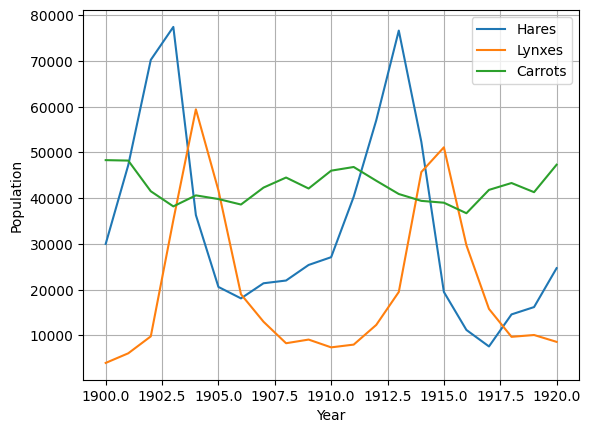

In [139]:
plt.plot(year, hares, label='Hares')    
plt.plot(year, lynxes, label='Lynxes')
plt.plot(year, carrots, label='Carrots')
plt.legend()
plt.grid(True)
plt.ylabel('Population')
plt.xlabel('Year')
plt.show()

In [140]:
populations = np.array([hares, lynxes, carrots])
print("=== Statistics ===")
print(f"Mean:   Hares={hares.mean():.0f}, Lynxes={lynxes.mean():.0f}, Carrots={carrots.mean():.0f}")
print(f"Std:    Hares={hares.std():.0f}, Lynxes={lynxes.std():.0f}, Carrots={carrots.std():.0f}")
print(f"\nCorrelation matrix:\n{np.corrcoef(populations)}")

=== Statistics ===
Mean:   Hares=34081, Lynxes=20167, Carrots=42400
Std:    Hares=20898, Lynxes=16255, Carrots=3323

Correlation matrix:
[[ 1.          0.07189206 -0.01660378]
 [ 0.07189206  1.         -0.68057717]
 [-0.01660378 -0.68057717  1.        ]]


In [141]:
# Species with highest population each year
species = ['Hares', 'Lynxes', 'Carrots']
highest_idx = np.argmax(populations, axis=0)  # index of max for each year
print("\n=== Highest population each year ===")
for i, y in enumerate(year):
    print(f"{int(y)}: {species[highest_idx[i]]}")



=== Highest population each year ===
1900: Carrots
1901: Carrots
1902: Hares
1903: Hares
1904: Lynxes
1905: Lynxes
1906: Carrots
1907: Carrots
1908: Carrots
1909: Carrots
1910: Carrots
1911: Carrots
1912: Hares
1913: Hares
1914: Hares
1915: Lynxes
1916: Carrots
1917: Carrots
1918: Carrots
1919: Carrots
1920: Carrots


### Summarize:
* data.T para atribuir as colunas a um array
* plota
* faz um array pra tirar o mean etc
* argmax

## Kernel Density Estimate


Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method

In [143]:
N = 200
mean, std = 0, 2
x = np.random.normal(mean,std,N)

* COMO FAZER O BIN TA NO NOTEBOOK DE MONTE CARLO:
* Plot scaled histogram
* factor = dist.cdf(4) - dist.cdf(-4)
* hist, bin_edges = np.histogram(v, bins=100, density=True)
* bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
* plt.step(bin_centers, factor*hist, linewidth=2)

In [145]:
counts, edges = np.histogram(x,bins=20,density=False)
centers = (edges[:-1] + edges[1:])*0.5
errors = np.sqrt(counts)

([<matplotlib.axis.YTick at 0x263db44c390>,
 [Text(0, 0.0, '0'),
  Text(0, 3.0, '3'),
  Text(0, 6.0, '6'),
  Text(0, 9.0, '9'),
  Text(0, 12.0, '12'),
  Text(0, 15.0, '15'),
  Text(0, 18.0, '18'),
  Text(0, 21.0, '21'),
  Text(0, 24.0, '24')])

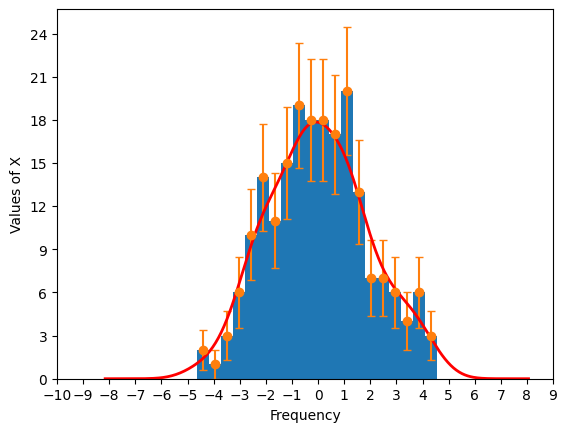

In [166]:
plt.hist(x, bins=20, histtype = 'bar')
plt.errorbar(centers, counts, yerr=errors, fmt='o',capsize=3)
plt.plot(x_range, kde_normalized, 'r-', lw=2, label='KDE')
plt.xlabel('Frequency')
plt.ylabel('Values of X')
plt.xticks(np.arange(np.floor(min(x))-5, np.ceil(max(x))+5,1))
plt.yticks(np.arange(0, max(counts)+max(errors),3))

Text(0.5, 1.0, 'Individual Gaussians (h=0.70)')

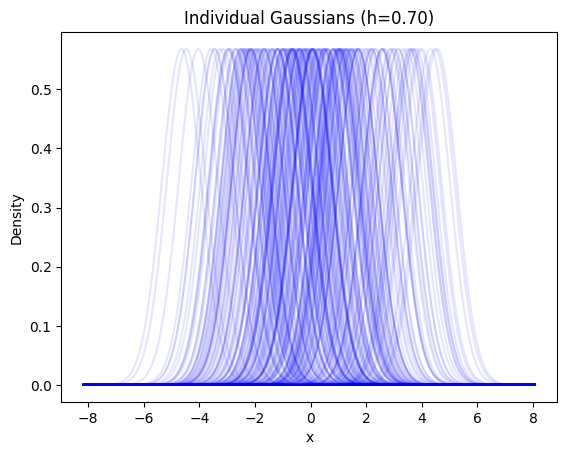

In [161]:
from scipy import stats, integrate

h = 1.06 * x.std() * N**(-1/5)

# x-range for plotting
x_range = np.linspace(x.min() - 5*h, x.max() + 5*h, 300)

# Plot individual Gaussians and sum
kde_sum = np.zeros_like(x_range)
for xi in x:
    gauss = stats.norm(loc=xi, scale=h).pdf(x_range)
    kde_sum += gauss
    plt.plot(x_range, gauss, 'b-', alpha=0.1)
plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Individual Gaussians (h={h:.2f})')


In [163]:
bin_width = edges[1] - edges[0]
hist_integral = counts.sum() * bin_width  # total area of histogram
kde_integral = integrate.trapezoid(kde_sum, x_range)
kde_normalized = kde_sum * hist_integral / kde_integral

### Summarize:
* faz a x random.normal
* pega os bins do notebook monte carlo
* plota tudo
* para fazer o kde: escreve o h (que é o std, e a mean é x)
* for xi in x: gera o stats.norm
* plota tudo
* normalize kde: bin widht edge[1] - edge[0]
* usa a func de integrar o trapezoide
* norm = kde_sum * hist_integral / kde integral


# Exam Version 5

## Diffusion using random walk


Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a row and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each row")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

In [168]:
walker = 1000
steps = 200
t_steps = 2 * np.random.randint(0,2, size=(walker,steps)) - 1
t_steps

array([[ 1,  1, -1, ...,  1,  1, -1],
       [-1, -1,  1, ..., -1, -1, -1],
       [ 1, -1, -1, ..., -1,  1,  1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [-1, -1,  1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1, -1,  1]], shape=(1000, 200), dtype=int32)

In [170]:
positions = np.cumsum(t_steps,axis=1)
positions

array([[  1,   2,   1, ...,   6,   7,   6],
       [ -1,  -2,  -1, ...,   0,  -1,  -2],
       [  1,   0,  -1, ...,   8,   9,  10],
       ...,
       [ -1,  -2,  -3, ..., -16, -17, -18],
       [ -1,  -2,  -1, ...,  14,  15,  16],
       [ -1,  -2,  -3, ...,   4,   3,   4]], shape=(1000, 200))

In [176]:
positions_squared = positions**2

# Mean squared displacement at each time step (average over walkers)
mean_sq_dist = np.mean(positions_squared, axis=0)
time = np.arange(1, steps+1, 1)
rms_dist = np.sqrt(mean_sq_dist)

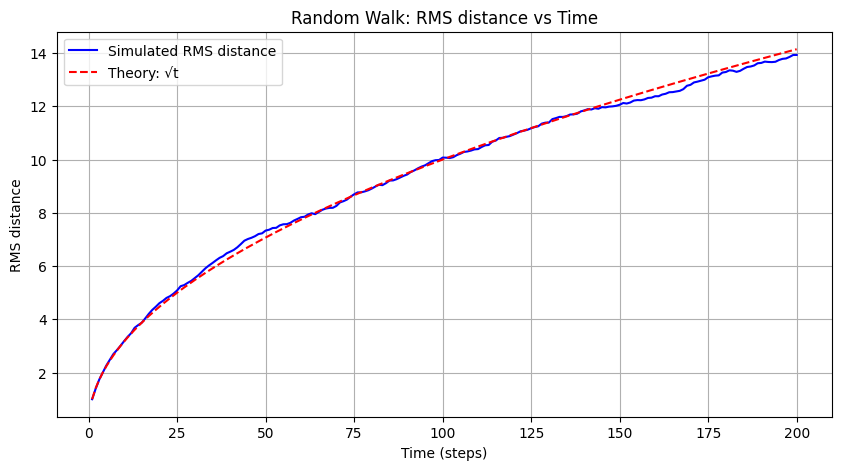

In [178]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, rms_dist, 'b-', label='Simulated RMS distance')
plt.plot(time, np.sqrt(time), 'r--', label='Theory: √t')
plt.xlabel('Time (steps)')
plt.ylabel('RMS distance')
plt.title('Random Walk: RMS distance vs Time')
plt.legend()
plt.grid(True)
plt.show()

### Summarize:
* só seguir o passo a passo do enunciado, vai printando para saber oq fazer
* expected: raiz de t

## Color-coded scatter plot

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [202]:
means = [0,5]
stds = [1,1]
lenghts = [300,250]

def generating2d(means,stds,lenghts):
    x11 = np.random.normal(means[0],stds[0],lenghts[0])
    x12 = np.random.normal(means[0],stds[0],lenghts[0])
    x1 = np.column_stack((x11,x12))

    x21 = np.random.normal(means[1],stds[1],lenghts[1])
    x22 = np.random.normal(means[1],stds[1],lenghts[1])
    x2 = np.column_stack((x21,x22))

    y1 = np.zeros(lenghts[0])
    y2 = np.ones(lenghts[1])

    x = np.vstack((x1,x2))
    y = np.hstack((y1,y2))

    return x,y

In [203]:
x,y = generating2d(means,stds,lenghts)

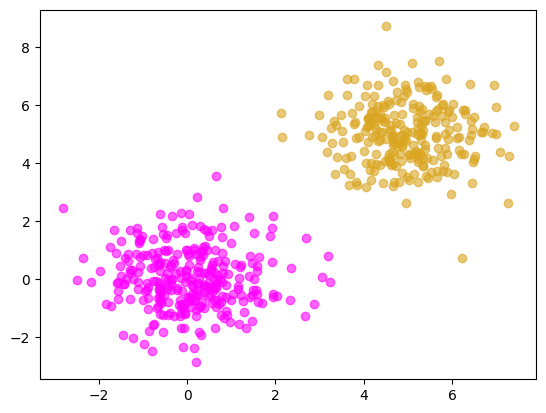

In [204]:
plt.scatter(
    x[y == 0, 0], x[y == 0, 1], #x is 2d, so i plot x[0] (x11) WHERE Y==0  and x[1](x12) WHERE Y==0
    color='fuchsia', alpha=0.6, label='Class 0')

plt.scatter(
    x[y == 1, 0], x[y == 1, 1],
    color='goldenrod', alpha=0.6, label='Class 1')

In [197]:
def generating(means, stds, lengths):

    x_all = []
    y_all = []

    for i in range(len(means)):

        # gera coordenada x
        xi = np.random.normal(
            means[i],
            stds[i],
            lengths[i]
        )

        # gera coordenada y
        yi = np.random.normal(
            means[i],
            stds[i],
            lengths[i]
        )

        # junta em uma matriz (x,y)
        points = np.column_stack((xi, yi))

        # guarda os pontos
        x_all.append(points)

        # guarda a categoria
        labels = np.ones(lengths[i]) * i
        y_all.append(labels)


    x = np.vstack(x_all)
    y = np.hstack(y_all)

    return x, y

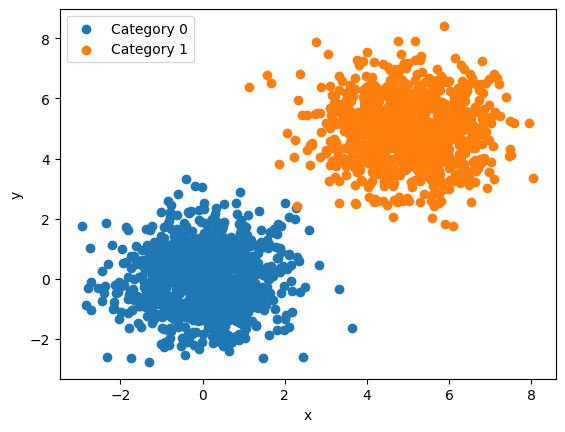

In [195]:
import matplotlib.pyplot as plt

for i in range(n_categories):
    
    plt.scatter(
        X[y==i,0],
        X[y==i,1],
        label=f'Category {i}',
    )

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Exam Version 2

## 2D minimization of a six-hump camelback function

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?

In [217]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def f(x,y):
    return (4 - 2.1*x**2 + (x**4/3))*x**2 + x*y + (4*y**2 - 4)*y**2

#def x e y PELO ENUNCIADO:
x = np.linspace(-2,2,200)
y = np.linspace(-1,1,200)
X, Y = np.meshgrid(x,y)
Z = f(X,Y)
Z

array([[5.73333333, 5.46922803, 5.2305339 , ..., 1.31093591, 1.50942903,
        1.73333333],
       [5.63483477, 5.37093148, 5.13243936, ..., 1.25223432, 1.45092946,
        1.67503578],
       [5.54027963, 5.27657835, 5.03828825, ..., 1.19747615, 1.3963733 ,
        1.62068164],
       ...,
       [1.62068164, 1.3963733 , 1.19747615, ..., 5.03828825, 5.27657835,
        5.54027963],
       [1.67503578, 1.45092946, 1.25223432, ..., 5.13243936, 5.37093148,
        5.63483477],
       [1.73333333, 1.50942903, 1.31093591, ..., 5.2305339 , 5.46922803,
        5.73333333]], shape=(200, 200))

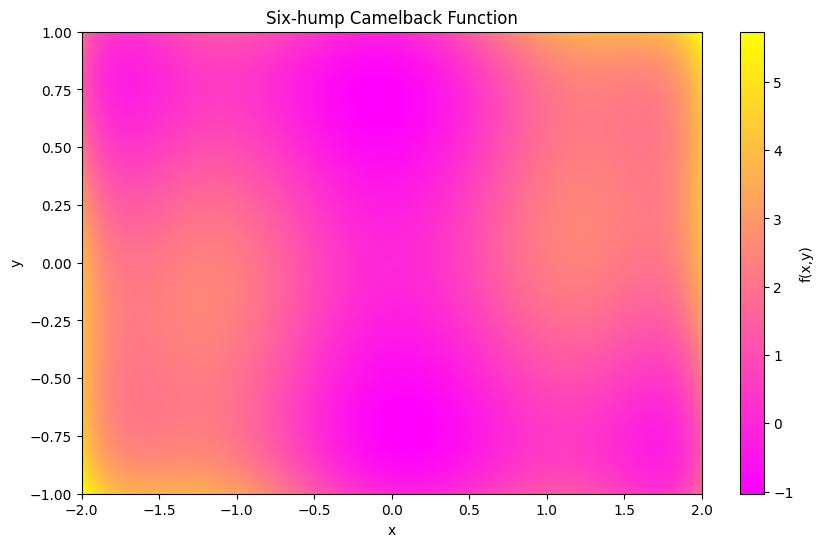

In [218]:
plt.figure(figsize=(10, 6))
plt.imshow(Z, extent=[-2, 2, -1, 1], origin='lower', cmap='spring', aspect='auto')
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Six-hump Camelback Function')
plt.show()

In [242]:
#NOW TO FIND THE MINIMAS - AND GLOBAL MINIMA
#define os initial guesses
st_points = [(0,0),(1,0),(-1,0),(-1,0.5),(1,-0.5)]

results = []
for point in st_points:
    x_min = minimize(lambda p: f(p[0],p[1]),point)
    results.append((x_min.x,x_min.fun))
    print(results)


# Find global minimum
min_val = min(r[1] for r in results) #r[1] is the function value, r[0] is the location pq eh onde a funcao eh minima
global_minima = [r for r in results if np.isclose(r[1], min_val, atol=1e-5)]
print(f"\n=== Global minima ===")
print(f"Number of global minima: {len(global_minima)}")
print(f"Function value: {min_val:.6f}")
for gm in global_minima:
    print(f"  Location: ({gm[0][0]:.4f}, {gm[0][1]:.4f})")


[(array([0., 0.]), np.float64(0.0))]
[(array([0., 0.]), np.float64(0.0)), (array([ 0.08984185, -0.71265649]), np.float64(-1.0316284534897004))]
[(array([0., 0.]), np.float64(0.0)), (array([ 0.08984185, -0.71265649]), np.float64(-1.0316284534897004)), (array([-0.08984187,  0.71265648]), np.float64(-1.0316284534897378))]
[(array([0., 0.]), np.float64(0.0)), (array([ 0.08984185, -0.71265649]), np.float64(-1.0316284534897004)), (array([-0.08984187,  0.71265648]), np.float64(-1.0316284534897378)), (array([-0.08984204,  0.71265645]), np.float64(-1.0316284534898543))]
[(array([0., 0.]), np.float64(0.0)), (array([ 0.08984185, -0.71265649]), np.float64(-1.0316284534897004)), (array([-0.08984187,  0.71265648]), np.float64(-1.0316284534897378)), (array([-0.08984204,  0.71265645]), np.float64(-1.0316284534898543)), (array([ 0.08984202, -0.71265647]), np.float64(-1.0316284534898417))]

=== Global minima ===
Number of global minima: 4
Function value: -1.031628
  Location: (0.0898, -0.7127)
  Locatio

## Use np.linspace to create an array of 100 numbers between 0 and 2π (inclusive)


  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

In [248]:
import numpy as np

array = np.linspace(0, 2*np.pi, 100)
print(array)

[0.         0.06346652 0.12693304 0.19039955 0.25386607 0.31733259
 0.38079911 0.44426563 0.50773215 0.57119866 0.63466518 0.6981317
 0.76159822 0.82506474 0.88853126 0.95199777 1.01546429 1.07893081
 1.14239733 1.20586385 1.26933037 1.33279688 1.3962634  1.45972992
 1.52319644 1.58666296 1.65012947 1.71359599 1.77706251 1.84052903
 1.90399555 1.96746207 2.03092858 2.0943951  2.15786162 2.22132814
 2.28479466 2.34826118 2.41172769 2.47519421 2.53866073 2.60212725
 2.66559377 2.72906028 2.7925268  2.85599332 2.91945984 2.98292636
 3.04639288 3.10985939 3.17332591 3.23679243 3.30025895 3.36372547
 3.42719199 3.4906585  3.55412502 3.61759154 3.68105806 3.74452458
 3.8079911  3.87145761 3.93492413 3.99839065 4.06185717 4.12532369
 4.1887902  4.25225672 4.31572324 4.37918976 4.44265628 4.5061228
 4.56958931 4.63305583 4.69652235 4.75998887 4.82345539 4.88692191
 4.95038842 5.01385494 5.07732146 5.14078798 5.2042545  5.26772102
 5.33118753 5.39465405 5.45812057 5.52158709 5.58505361 5.648520

In [247]:
tenths = array[::10]
print(tenths)

[0.         0.63466518 1.26933037 1.90399555 2.53866073 3.17332591
 3.8079911  4.44265628 5.07732146 5.71198664]


In [250]:
reverse = array[::-1]
print(reverse)

[6.28318531 6.21971879 6.15625227 6.09278575 6.02931923 5.96585272
 5.9023862  5.83891968 5.77545316 5.71198664 5.64852012 5.58505361
 5.52158709 5.45812057 5.39465405 5.33118753 5.26772102 5.2042545
 5.14078798 5.07732146 5.01385494 4.95038842 4.88692191 4.82345539
 4.75998887 4.69652235 4.63305583 4.56958931 4.5061228  4.44265628
 4.37918976 4.31572324 4.25225672 4.1887902  4.12532369 4.06185717
 3.99839065 3.93492413 3.87145761 3.8079911  3.74452458 3.68105806
 3.61759154 3.55412502 3.4906585  3.42719199 3.36372547 3.30025895
 3.23679243 3.17332591 3.10985939 3.04639288 2.98292636 2.91945984
 2.85599332 2.7925268  2.72906028 2.66559377 2.60212725 2.53866073
 2.47519421 2.41172769 2.34826118 2.28479466 2.22132814 2.15786162
 2.0943951  2.03092858 1.96746207 1.90399555 1.84052903 1.77706251
 1.71359599 1.65012947 1.58666296 1.52319644 1.45972992 1.3962634
 1.33279688 1.26933037 1.20586385 1.14239733 1.07893081 1.01546429
 0.95199777 0.88853126 0.82506474 0.76159822 0.6981317  0.634665

In [252]:
sin = np.sin(array)
cos = np.cos(array)
mask = np.abs(sin - cos) < 0.1
absdif = array[mask]
print(absdif)

[0.76159822 0.82506474 3.87145761 3.93492413]


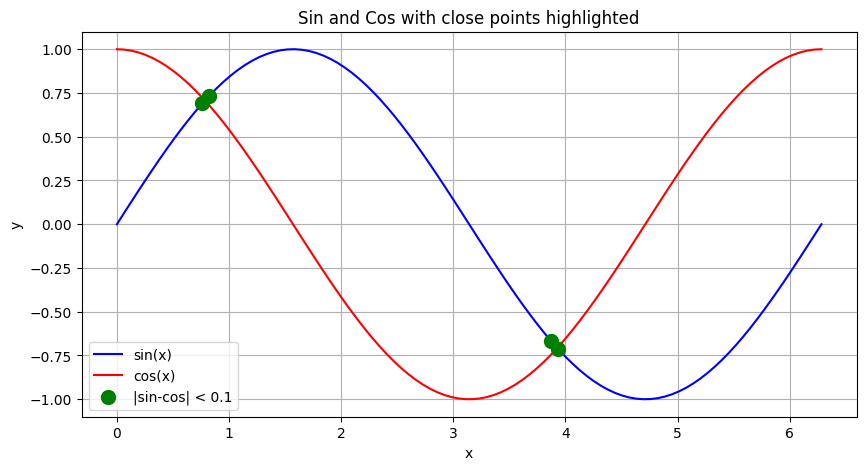

In [253]:
# Plot sin and cos, marking where they are close
plt.figure(figsize=(10, 5))
plt.plot(array, sin, 'b-', label='sin(x)')
plt.plot(array, cos, 'r-', label='cos(x)')
plt.scatter(absdif, np.sin(absdif), c='green', s=100, zorder=5, label='|sin-cos| < 0.1')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sin and Cos with close points highlighted')
plt.legend()
plt.grid(True)
plt.show()

## PCA on a 3D dataset

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.

In [255]:
np.random.seed(42)
N = 2000

x1 = np.random.normal(0,1,N)
x2 = x1 + np.random.normal(0,3,N)
x3 = 2*x1+x2

In [258]:
#Gerar matrix com o dataset:
data = np.column_stack([x1,x2,x3])
data_center = data - data.mean(axis=0)
print(data_center)

[[ 0.45163001 -1.55457731 -0.6513173 ]
 [-0.18334845 -0.59757696 -0.96427385]
 [ 0.60260439 -1.75532787 -0.55011908]
 ...
 [-0.9269588  -1.86852471 -3.7224423 ]
 [-0.20815111  4.74131086  4.32500864]
 [-0.78998679  0.31128439 -1.26868919]]


In [ ]:
cov_matrix = np.cov(data_center.T)
print(cov_matrix.shape)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("=== Covariance matrix method ===")
print(f"Eigenvalues: {eigenvalues}")

(3, 3)
=== Covariance matrix method ===
Eigenvalues: [ 2.65055253e+01  2.01132023e+00 -2.34482196e-14]
